In [1]:
# import함수 호출
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [9]:
# 데이터 로드 및 결합 (Merging)

# 데이터 불러오기
y_label = pd.read_csv('Y_label_dataset_n_aligned.csv')
market_data = pd.read_csv('merged_all_quarterly.csv')

# 종목코드 형식을 정수형(int)으로 통일
y_label['stock_code'] = y_label['stock_code'].fillna(0).astype(int)
market_data['stock_code'] = market_data['stock_code'].astype(int)

# 두 데이터를 종목코드와 분기 기준으로 병합
merged_df = pd.merge(
    market_data,
    y_label[['stock_code', 'quarter', '감사의견']],
    on=['stock_code', 'quarter'],
    how='inner'
)

In [10]:
# 시장 데이터에서의 없는 데이터(결측치)들 제거
df_drop = merged_df.dropna()

name = 'only.csv'

df_drop.to_csv(name, index=False, encoding='utf-8-sig')

In [11]:
# X,Y test, train 데이터 분리

# 1. 데이터 로드 및 정렬
df_only = pd.read_csv('only.csv', encoding='utf-8-sig')
df_only = df_only.sort_values(by=['quarter', 'stock_code']) # 시계열 순서로 정렬

# 2. 분기 리스트 확인
quarters = sorted(df_only['quarter'].unique())
print(f"전체 분기 범위: {quarters[0]} ~ {quarters[-1]}")

# 3. 분리 시점 설정 (예: 마지막 4개 분기를 테스트셋으로 활용)
test_quarters = quarters[-4:]
train_quarters = quarters[:-4]

print(f"학습 분기: {train_quarters[0]} ~ {train_quarters[-1]}")
print(f"테스트 분기: {test_quarters[0]} ~ {test_quarters[-1]}")

# 4. 데이터 분할 실행
train_df = df_only[df_only['quarter'].isin(train_quarters)].copy()
test_df = df_only[df_only['quarter'].isin(test_quarters)].copy()

# 5. X, y 정의
features = ['Open', 'High', 'Low', 'Close', 'Volume_sum', 'ret_1q', 'vol_4q', 'max_drawdown_4q', 'ma4_ratio']
X_train = train_df[features]
y_train = train_df['감사의견']

X_test = test_df[features]
y_test = test_df['감사의견']

전체 분기 범위: 2021Q1 ~ 2025Q3
학습 분기: 2021Q1 ~ 2024Q3
테스트 분기: 2024Q4 ~ 2025Q3


In [12]:
# 분리 시점 결정 (예: 2023Q4까지 학습, 2024Q1부터 테스트)
# 데이터 내의 실제 quarter 값을 확인하여 적절한 절단 지점을 선택하세요.
train_df = df_drop[df_drop['quarter'] <= '2023Q4'].copy()
test_df = df_drop[df_drop['quarter'] >= '2024Q1'].copy()

# 독립변수(X)와 종속변수(y) 정의
features = ['Open', 'High', 'Low', 'Close', 'Volume_sum', 'ret_1q', 'vol_4q', 'max_drawdown_4q', 'ma4_ratio']

X_train = train_df[features]
y_train = train_df['감사의견']

X_test = test_df[features]
y_test = test_df['감사의견']

# 3. CSV 파일로 내보내기
X_train.to_csv('X_train.csv', index=False, encoding='utf-8-sig')
y_train.to_csv('y_train.csv', index=False, encoding='utf-8-sig')
X_test.to_csv('X_test.csv', index=False, encoding='utf-8-sig')
y_test.to_csv('y_test.csv', index=False, encoding='utf-8-sig')

print("파일 저장 완료: X_train.csv, y_train.csv, X_test.csv, y_test.csv")
print(f"학습 데이터 수: {len(X_train)}건")
print(f"테스트 데이터 수: {len(X_test)}건")

파일 저장 완료: X_train.csv, y_train.csv, X_test.csv, y_test.csv
학습 데이터 수: 24185건
테스트 데이터 수: 15582건


In [13]:
# 전처리 및 점수 매핑 (Scoring)

# 4. 감사의견 점수 매핑 및 피처 설정
score_mapping = {
    '적정': 0,
    '한정': 1,
    '기타/확인필요': 2,
    '부적정': 3,
    '의견거절': 3
}

# 숫자형 피처만 추출 (식별값 제외)
features = df_drop.select_dtypes(include=[np.number]).columns.drop(['stock_code']).tolist()

X = df_drop[features]
y = df_drop['감사의견']
y_score = df_drop['감사의견'].map(score_mapping)

# 모델 1 : Randomforest

선정 이유 : 감사의견은 '적정', '기타/의견필요'들이 압도적으로 많다. Random Forest는 class_weight='balanced'와 같은 설정을 통해 소수인 '부적정', '한정', '의견부족' 데이터를 더 중요하게 취급하도록 학습가능.

In [14]:
# 모델 학습

# 훈련, 테스트 데이터 업로
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').values.ravel() # 1차원 배열로 변환
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').values.ravel()

# RandomForest 모델
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 훈련 데이터(X_train, y_train)로 학습
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=50,
                       n_jobs=-1, random_state=42)

In [15]:
#예측 및 결과 정리 (Final Result)

# 1. 예측 수행
y_pred = model.predict(X_test)

print("=== 모델 성능 평가 (Test Set) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\n[Classification Report]")
# 0:적정, 1:한정, 2:기타, 3:부적정/거절
print(classification_report(y_test, y_pred))


=== 모델 성능 평가 (Test Set) ===
Accuracy: 0.2599

[Classification Report]
              precision    recall  f1-score   support

     기타/확인필요       0.86      0.18      0.29     13410
        의견거절       0.29      0.59      0.39       133
          적정       0.13      0.79      0.22      2031
          한정       0.00      0.00      0.00         8

    accuracy                           0.26     15582
   macro avg       0.32      0.39      0.23     15582
weighted avg       0.76      0.26      0.28     15582



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


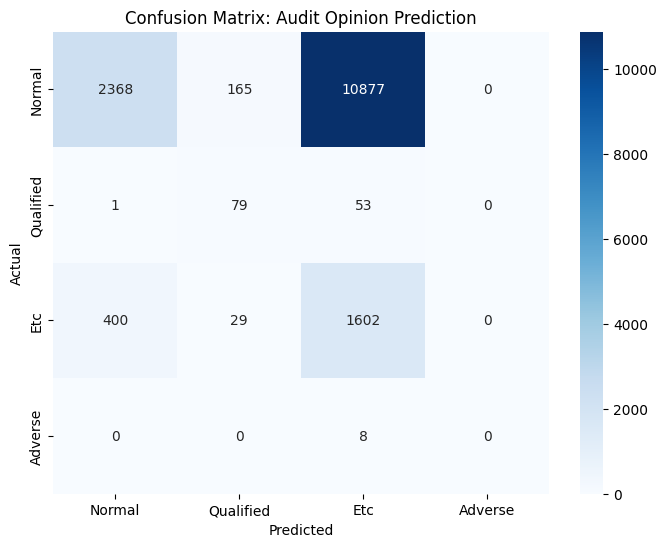

In [18]:
# 혼동 행렬(Confusion Matrix) 시각화
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Qualified', 'Etc', 'Adverse'],
            yticklabels=['Normal', 'Qualified', 'Etc', 'Adverse'])
plt.title('Confusion Matrix: Audit Opinion Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# n차 모델

In [19]:
# 반복적인 모델의 가중치, 하이퍼파라메타 변형

# 사용할 피처 정의
features = merged_df.select_dtypes(include=[np.number]).columns.tolist()
features = [f for f in features if f not in ['stock_code']] # 식별용 코드는 제외
X = merged_df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

y_score = merged_df['감사의견'].map(score_mapping)
y_label_name = merged_df['감사의견'] # 이름 비교용

# 과적합을 유도하는 모델 설정
model12 = RandomForestClassifier(
    n_estimators=200,     # 트리를 많이 쌓아 정밀도 향상
    max_depth=225,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 전체 데이터로 학습 수행
model12.fit(X, y_label_name)

RandomForestClassifier(class_weight='balanced', max_depth=225,
                       min_samples_leaf=5, n_estimators=500, n_jobs=-1,
                       random_state=42)

In [24]:
# 모델 예측 및 결과 정리

# 예측
y_pred_name = model12.predict(X)

# 결과 데이터프레임 생성
results = merged_df[['stock_code', 'Name', 'quarter', '감사의견']].copy()
results['actual_score'] = y_score # y_score는 merged_df 기반이므로 길이 일치
results['predicted_opinion'] = y_pred_name
results['predicted_score'] = results['predicted_opinion'].map(score_mapping)

# 일치 여부 확인
results['is_match'] = (results['감사의견'] == results['predicted_opinion'])

# 성능 출력 (model12의 전체 데이터에 대한 성능 평가)
print(f"Accuracy: {accuracy_score(results['감사의견'], y_pred_name):.4f}")
print("\n--- 감사의견 분류 보고서 ---")
print(classification_report(results['감사의견'], y_pred_name))


Accuracy: 0.9445

--- 감사의견 분류 보고서 ---
              precision    recall  f1-score   support

     기타/확인필요       0.95      0.93      0.94     21132
         부적정       1.00      1.00      1.00         2
        의견거절       0.40      1.00      0.57       593
          적정       0.96      0.95      0.96     30944
          한정       0.89      1.00      0.94        54

    accuracy                           0.94     52725
   macro avg       0.84      0.98      0.88     52725
weighted avg       0.95      0.94      0.95     52725



In [21]:
# 결과 파일 저장
results.to_csv('prediction_audit_opinion.csv', index=False, encoding='utf-8-sig')

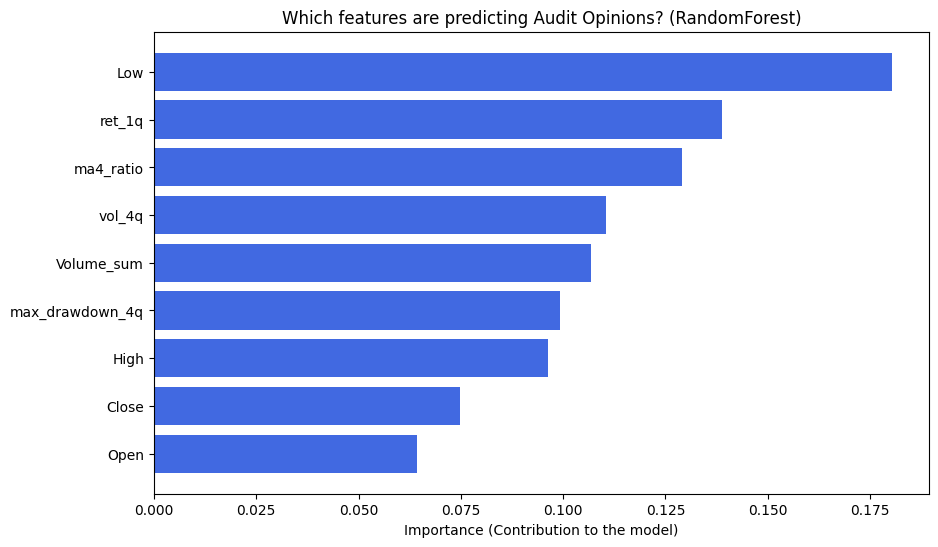

           Feature  Importance
2              Low    0.180322
5           ret_1q    0.138713
8        ma4_ratio    0.129019
6           vol_4q    0.110462
4       Volume_sum    0.106893
7  max_drawdown_4q    0.099234
1             High    0.096332
3            Close    0.074680
0             Open    0.064345


In [22]:
# 변수 중요도 파악
import matplotlib.pyplot as plt

# 변수 중요도 추출 (RandomForest는 feature_importances_ 사용)
importances = model.feature_importances_

# 변수 이름을 피처 리스트와 매칭
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='royalblue')
plt.gca().invert_yaxis()
plt.title('Which features are predicting Audit Opinions? (RandomForest)')
plt.xlabel('Importance (Contribution to the model)')
plt.show()

print(importance_df)

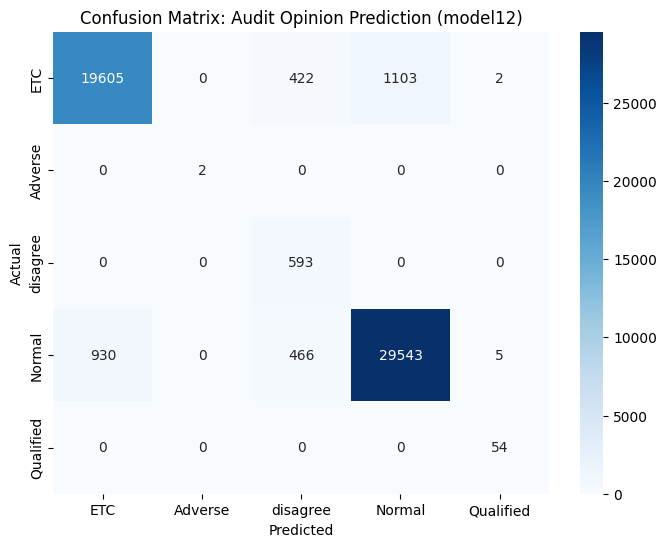

In [31]:
# 혼동 행렬(Confusion Matrix) 시각화
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 실제 감사의견 카테고리 추출 및 정렬 (confusion_matrix의 기본 정렬 순서에 맞춤)
actual_labels_korean = np.array(sorted(results['감사의견'].unique()))

# 한글 라벨을 영어 라벨로 매핑
korean_to_english_map = {
    '기타/확인필요': 'Other/Needs Confirm',
    '부적정': 'Adverse',
    '의견거절': 'Disclaimer',
    '적정': 'Unqualified',
    '한정': 'Qualified'
}

# 매핑된 영어 라벨 리스트 생성
english_labels = [korean_to_english_map[label] for label in actual_labels_korean]

plt.figure(figsize=(10, 8)) # 차트 크기 조정
cm = confusion_matrix(results['감사의견'], results['predicted_opinion'], labels=actual_labels_korean)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=english_labels,
            yticklabels=english_labels)
plt.title('Confusion Matrix: Audit Opinion Prediction (Model 12)', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout() # 라벨이 잘리지 않도록 조정
plt.show()